In [86]:
import torch
w = 'hello world I like dogs and cats that eat dog meat'
words = list(w)
chars = list(set(w))
data_size, vocab_size = len(words), len(chars)
ctoi = { ch:i for i,ch in enumerate(chars) }
itoc = { ch:i for i,ch in ctoi.items() }
print(len(itoc))


18


In [60]:
g = torch.Generator().manual_seed(123)

In [131]:

n_hidd = 15 # size of hidden layer of neurons
Wxh = torch.randn((vocab_size,n_hidd), generator=g) * 0.01 # we'll work with columns vectors
Whh = torch.randn((n_hidd, n_hidd), generator=g) * 0.01
Why = torch.randn((n_hidd, vocab_size), generator=g) * 0.01
bh = torch.randn((1,n_hidd)) * 0
by = torch.randn((1, vocab_size)) * 0



parameters = [Wxh, Whh, Why,bh,by]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.grad = None
    p.requires_grad = True

import torch.nn.functional as F

798


In [98]:
Xtr = words[:-1]
Ytr = words[1:]

In [106]:
def predict(seed, n_chars):
    h = torch.zeros((1, n_hidd))
    
    result = seed
    for c in seed:    
        ix = ctoi[c]
        h = torch.tanh(Wxh[ix, :] + h @ Whh + bh)
    for _ in range(n_chars):
        logits = h @ Why + by
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, 1).item()
        
        c = itoc[ix]
        result += c
        h = torch.tanh(Wxh[ix, :] + h @ Whh + bh)
    
    return result

print(predict('h', n_chars=9)) 

hm ghwIade


prediction du modèle à 0 epoch: hatortorlortoglort atog
prediction du modèle à 25 epoch: htnosktodaIoogtkkdtsrir
prediction du modèle à 50 epoch: hlnogeletltsl   danesr 
prediction du modèle à 75 epoch: hhnoretgt lrhllloliillr
prediction du modèle à 100 epoch: hlohtehoosdsrrrrooowhsh
prediction du modèle à 125 epoch: ha Ig aereraotoss eirtl
prediction du modèle à 150 epoch: hlooacllonoooonrrrdkrln
prediction du modèle à 175 epoch: heo lldogo l llmodrwdrd
prediction du modèle à 200 epoch: hlo asdno alolwal l daa
prediction du modèle à 225 epoch: htooaidragedlhsrgddooor
prediction du modèle à 250 epoch: haootaooewrsooriwokootg
prediction du modèle à 275 epoch: hl d It  dnacl   hrtte 
prediction du modèle à 300 epoch: hto aelooac dggkaaesdo 
prediction du modèle à 325 epoch: htnd aarsrlodrlknhreorg
prediction du modèle à 350 epoch: haoo rrroddorerhrorlrso
prediction du modèle à 375 epoch: hleg leegello  aklslrrr
prediction du modèle à 400 epoch: hthm  aro  lls   ld   l
prediction du modèl

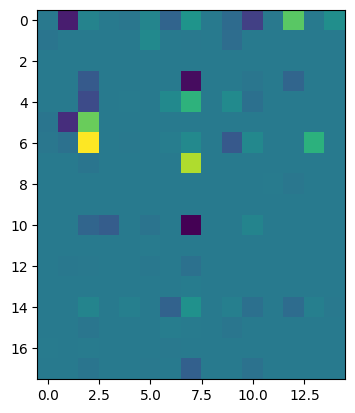

In [ ]:
lr = 0.05
n_step = 1000
h0 = torch.zeros((1,n_hidd))
lossi = []
for j in range(n_step):
    hp = h0
    loss = 0
    for p in parameters:
        p.grad = None
        p.requires_grad = True
        ht, logits, probs = {}, {}, {}
    for i in range(len(Xtr)):
        ix = ctoi[Xtr[i]]
        iy = ctoi[Ytr[i]]
        #forward pass
        ht[i] = torch.tanh(Wxh[ix,:] + hp @ Whh + bh) 
        hp = ht[i]
        logits[i] = ht[i] @ Why + by
        probs[i] = torch.softmax(logits[i],dim=1)
        log_probs = probs[i].log()
        loss += -log_probs[0,iy]
    lossi.append(loss.item())
    h0 = hp.detach()
    ######### backward manually #############""
    # dWhh, dWxh, dWhy = torch.zeros_like(Whh), torch.zeros_like(Wxh), torch.zeros_like(Why)
    # dby, dbh = torch.zeros_like(by), torch.zeros_like(bh)
    # dhn = torch.zeros((1,n_hidd))
    # for i in range(len(Xtr)-1,0,-1):
    #      dy = probs[i]
    #      dy[Ytr[i]] += -1
    #      dby += dy
    #      dWhy += ht[i].T @ dy
    #      dh = dy @ Why.T + dhn 
    #      dhraw = (1-ht[i]**2) * dh
    #      dbh += dhraw
    #      dWhh += ht[i-1].T @ dhraw
    #      dWxh[:,ctoi[Xtr[i]]] += dhraw
    #      dhn = dhraw @ Whh.T
    loss.backward()
    for p in parameters:
            p.data += -lr * p.grad
    if j%25==0:
         print(f'prediction du modèle à {j} epoch: {predict('h',22)}')
import matplotlib.pyplot as plt
plt.imshow(torch.detach(Wxh).numpy())


In [102]:
predict('h',22)

'haaae ooerto saa  amg a'

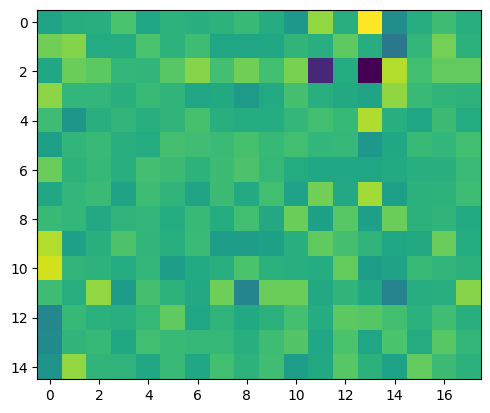

In [103]:
plt.imshow(torch.detach(Why).numpy())

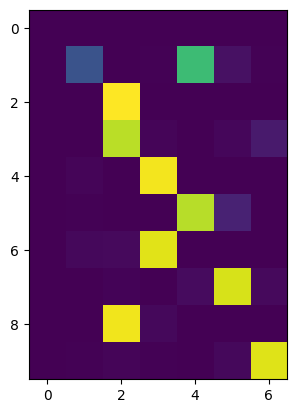

In [ ]:
plt.imshow(torch.detach(po).numpy())

In [ ]:
lr = 0.05
n_step = 1
h0 = torch.zeros((1,n_hidd))
lossi = []
for j in range(n_step):
    hp = h0
    loss = 0
    for p in parameters:
        p.grad = None
        p.requires_grad = True
        ht, logits, probs = {}, {}, {}
        ht[-1] = torch.zeros((1,n_hidd))
    for i in range(len(Xtr)):
        ix = ctoi[Xtr[i]]
        iy = ctoi[Ytr[i]]
        #forward pass
        ht[i] = torch.tanh(Wxh[ix,:] + hp @ Whh + bh) 
        hp = ht[i]
        logits[i] = ht[i] @ Why + by
        probs[i] = torch.softmax(logits[i],dim=1)
        log_probs = probs[i].log()
        loss += -log_probs[0,iy]
    lossi.append(loss.item())
    h0 = hp.detach()
    # backward manually
    loss.backward()
    with torch.no_grad():
        dWhh, dWxh, dWhy = torch.zeros_like(Whh), torch.zeros_like(Wxh), torch.zeros_like(Why)
        dby, dbh = torch.zeros_like(by), torch.zeros_like(bh)
        dhn = torch.zeros((1,n_hidd))
        for i in range(len(Xtr)-1,-1,-1):
            dy = dy = probs[i].detach().clone()
            dy[0,ctoi[Ytr[i]]] += -1
            dby += dy
            dWhy += ht[i].T @ dy
            dh = dy @ Why.T + dhn 
            dhraw = (1-ht[i]**2) * dh
            dbh += dhraw
            dWhh += ht[i-1].T @ dhraw
            dWxh[ctoi[Xtr[i]],:] += dhraw.squeeze(0)
            dhn = dhraw @ Whh.T

    for name, param, g_man in [
        ("Wxh", Wxh, dWxh),
        ("Whh", Whh, dWhh),
        ("bh",  bh,  dbh),
        ("Why", Why, dWhy),
        ("by",  by,  dby),
    ]:
        diff = (param.grad - g_man).abs().max().item()
        print(f"{name}: max diff = {diff:.2e}")